# Notebook 1: Data Collection

This notebook downloads and processes all data required for the Patagonia windhydro energy drought analysis:

1. ERA5 reanalysis variables (wind, precipitation, runoff, temperature, snowmelt)
2. Climate mode indices (SAM, ONI, IOD)
3. Unit conversions and quality checks
4. Area-averaged timeseries for the study region

**Study Region:** 38°S–47.5°S, 72°W–62°W (Northern Patagonia energy corridor)  
**Period:** 1979–2025  
**Resolution:** 0.25° monthly

## Imports

In [4]:
import os
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import cdsapi
import regionmask
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import zipfile
import urllib.request

warnings.filterwarnings("ignore", category=FutureWarning)

## Defining Constants

In [5]:
# Patagonia region bounding box
NORTH = -38.0
SOUTH = -47.5
WEST = -72.0
EAST = -62.0

# Timeframe
YEAR_START = 1979
YEAR_END = 2025

# filepaths
RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
METADATA_DIR = "../data/metadata"

## ERA5 Install

In [6]:
client = cdsapi.Client()

# Define the variables and file I want to install from CDS api
era5_variables = {
    "single_levels": {
        "dataset": "reanalysis-era5-single-levels-monthly-means",
        "product_type": "monthly_averaged_reanalysis",
        "variables": [
            "100m_u_component_of_wind",
            "100m_v_component_of_wind",
            "2m_temperature",
            "total_precipitation",
            "runoff",
            "snowmelt",
        ],
    }
}

years = [str(y) for y in range(YEAR_START, YEAR_END + 1)]
months = [str(m).zfill(2) for m in range(1, 13)]

filepath = os.path.join(RAW_DIR, "era5_monthly_patagonia.nc")

# Install the file from CDS api
if not os.path.exists(filepath):
    client.retrieve(
        era5_variables["single_levels"]["dataset"],
        {
            "product_type": era5_variables["single_levels"]["product_type"],
            "variable": era5_variables["single_levels"]["variables"],
            "year": years,
            "month": months,
            "time": "00:00",
            "area": [NORTH, WEST, SOUTH, EAST],
            "format": "netcdf",
        },
        filepath,
    )
    print(f"Downloaded ERA5 data to {filepath}")
else:
    print(f"ERA5 data already exists at {filepath}")

2026-05-04 20:34:55,401 INFO Request ID is 74a31ab9-4fa7-488d-bb50-ca4fcef01a95
2026-05-04 20:34:55,705 INFO status has been updated to accepted
2026-05-04 20:39:19,695 INFO status has been updated to successful


8abd0981f3e9349023d8a90f91391a53.zip:   0%|          | 0.00/7.98M [00:00<?, ?B/s]

Downloaded ERA5 data to ../data/raw/era5_monthly_patagonia.nc


## Unzipping and remerging the CDS install

In [7]:
# Needs to be unzipped as CDS still hasn't fixed them giving
# you a zipped file of avgad and avgua variables despite requesting a netcdf
if zipfile.is_zipfile(filepath):
    print("Downloaded file is a ZIP archive. extracting...")

    with zipfile.ZipFile(filepath, "r") as z:
        print(f"ZIP contents: {z.namelist()}")
        z.extractall(RAW_DIR)

        nc_files = [f for f in z.namelist() if f.endswith(".nc")]
        print(f"Found {len(nc_files)} NetCDF files: {nc_files}")
else:
    nc_filepath = filepath
    print("File is already NetCDF format")

# Open each file and inspect before merging
datasets = {}
for f in nc_files:
    fpath = os.path.join(RAW_DIR, f)
    ds_temp = xr.open_dataset(fpath)

    if "valid_time" in ds_temp.dims:
        ds_temp = ds_temp.rename({"valid_time": "time"})

    ds_temp["time"] = ds_temp.time.values.astype("datetime64[M]").astype(
        "datetime64[ns]"
    )

    print(f"\n{f}:")
    print(f"  Variables: {list(ds_temp.data_vars)}")
    print(f"  Time[0]: {ds_temp.time.values[0]}")
    print(f"  Time[-1]: {ds_temp.time.values[-1]}")
    datasets[f] = ds_temp

# Merge into single dataset
ds = xr.merge(datasets.values())

print("\nMerged dataset:")
print(f"  Variables: {list(ds.data_vars)}")
print(f"  Time range: {ds.time.values[0]} to {ds.time.values[-1]}")
print(
    f"  Latitude range: {ds.latitude.values.min():.2f} to {ds.latitude.values.max():.2f}"
)
print(
    f"  Longitude range: {ds.longitude.values.min():.2f} to {ds.longitude.values.max():.2f}"
)
print(f"  Grid size: {len(ds.latitude)} x {len(ds.longitude)}")

print("\nAll variables:")
for var in ds.data_vars:
    print(f"  {var}: {ds[var].dims}, units: {ds[var].attrs.get('units', 'unknown')}")

Downloaded file is a ZIP archive. extracting...
ZIP contents: ['data_stream-moda_stepType-avgua.nc', 'data_stream-moda_stepType-avgad.nc']
Found 2 NetCDF files: ['data_stream-moda_stepType-avgua.nc', 'data_stream-moda_stepType-avgad.nc']

data_stream-moda_stepType-avgua.nc:
  Variables: ['u100', 'v100', 't2m']
  Time[0]: 1979-01-01T00:00:00.000000000
  Time[-1]: 2025-12-01T00:00:00.000000000

data_stream-moda_stepType-avgad.nc:
  Variables: ['tp', 'ro', 'smlt']
  Time[0]: 1979-01-01T00:00:00.000000000
  Time[-1]: 2025-12-01T00:00:00.000000000

Merged dataset:
  Variables: ['u100', 'v100', 't2m', 'tp', 'ro', 'smlt']
  Time range: 1979-01-01T00:00:00.000000000 to 2025-12-01T00:00:00.000000000
  Latitude range: -47.50 to -38.00
  Longitude range: -72.00 to -62.00
  Grid size: 39 x 41

All variables:
  u100: ('time', 'latitude', 'longitude'), units: m s**-1
  v100: ('time', 'latitude', 'longitude'), units: m s**-1
  t2m: ('time', 'latitude', 'longitude'), units: K
  tp: ('time', 'latitude'

## Converting the units to correct ones + New Dataset

In [8]:
# Wind speed from u and v components
# wind_speed = sqrt(u^2 + v^2)
wind_speed = np.sqrt(ds["u100"] ** 2 + ds["v100"] ** 2)
wind_speed.attrs["units"] = "m/s"
wind_speed.attrs["long_name"] = "100m wind speed"

# Temperature: Kelvin to Celsius
temperature = ds["t2m"] - 273.15
temperature.attrs["units"] = "°C"
temperature.attrs["long_name"] = "2m temperature"

# Precipitation: m/day to mm/month
# ERA5 monthly means give average daily rate in metres
# Multiply by 1000 (m to mm) and by days in each month
days_in_month = ds.time.dt.days_in_month
precipitation = ds["tp"] * 1000 * days_in_month
precipitation.attrs["units"] = "mm/month"
precipitation.attrs["long_name"] = "Total precipitation"

# Runoff: same conversion as precipitation
runoff = ds["ro"] * 1000 * days_in_month
runoff.attrs["units"] = "mm/month"
runoff.attrs["long_name"] = "Total runoff"

# Snowmelt: same conversion as precipitation
snowmelt = ds["smlt"] * 1000 * days_in_month
snowmelt.attrs["units"] = "mm/month"
snowmelt.attrs["long_name"] = "Snowmelt"

# Combine into a clean dataset
ds_converted = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "temperature": temperature,
        "precipitation": precipitation,
        "runoff": runoff,
        "snowmelt": snowmelt,
    }
)

print("Converted dataset:")
print(ds_converted)

Converted dataset:
<xarray.Dataset> Size: 29MB
Dimensions:        (time: 564, latitude: 39, longitude: 41)
Coordinates:
  * time           (time) datetime64[ns] 5kB 1979-01-01 ... 2025-12-01
    expver         (time) <U4 9kB '0001' '0001' '0001' ... '0001' '0001' '0001'
  * latitude       (latitude) float64 312B -38.0 -38.25 -38.5 ... -47.25 -47.5
  * longitude      (longitude) float64 328B -72.0 -71.75 -71.5 ... -62.25 -62.0
    number         int64 8B 0
Data variables:
    wind_speed     (time, latitude, longitude) float32 4MB 3.417 1.317 ... 6.722
    temperature    (time, latitude, longitude) float32 4MB 15.85 15.39 ... 12.13
    precipitation  (time, latitude, longitude) float64 7MB 22.05 32.4 ... 13.45
    runoff         (time, latitude, longitude) float64 7MB 24.83 25.87 ... 0.0
    snowmelt       (time, latitude, longitude) float64 7MB 0.0 0.0 ... 0.0 0.0


## Create land sea mask

Total grid cells: 1599
Land grid cells: 1186
Ocean grid cells: 413
Land fraction: 74.2%


/home/sgosmyt2/miniconda3/envs/patagonia-energy/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/sgosmyt2/miniconda3/envs/patagonia-energy/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


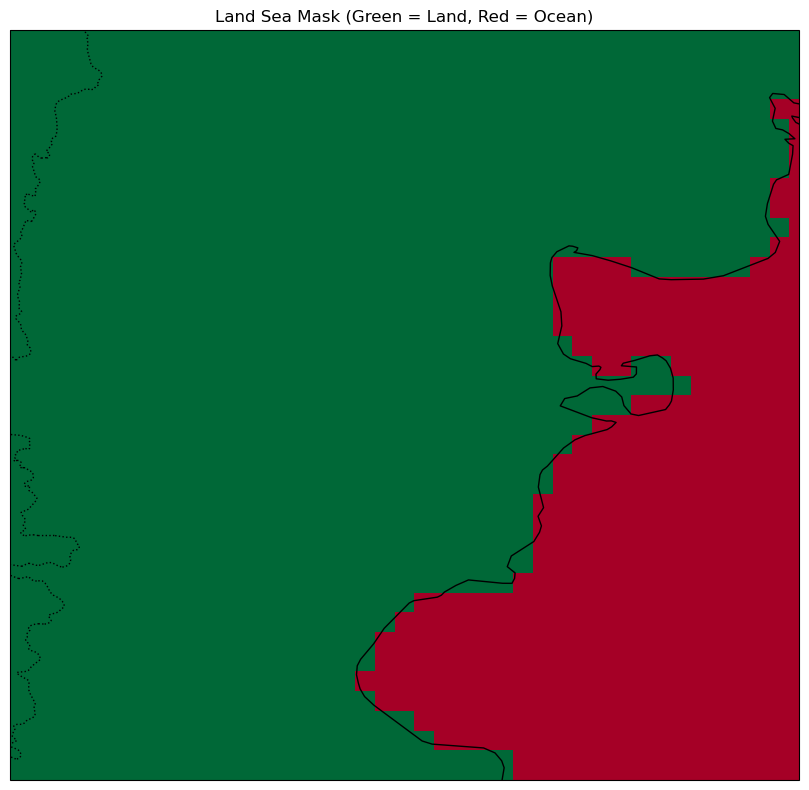

In [9]:
# Creating a land mask with regionmask, its sufficiently accurate to not meaningfully affect the data
# This is to prevent the ocean tiles from contaminating the area averages
land_mask = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(
    ds_converted["longitude"], ds_converted["latitude"]
)

is_land = ~np.isnan(land_mask)

print(f"Total grid cells: {is_land.size}")
print(f"Land grid cells: {is_land.sum().values}")
print(f"Ocean grid cells: {(~is_land).sum().values}")
print(f"Land fraction: {is_land.sum().values / is_land.size:.1%}")

# Visualise the mask to verify it
fig, ax = plt.subplots(
    1, 1, figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()}
)
is_land.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdYlGn",
    add_colorbar=False,
)
ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title("Land Sea Mask (Green = Land, Red = Ocean)")
ax.set_extent([WEST, EAST, SOUTH, NORTH], crs=ccrs.PlateCarree())

plt.tight_layout()

In [10]:
# Modify the dataset with the mask if it all comes out ok
ds_masked = ds_converted.where(is_land)

## Computer Area Weight Averages

In [11]:
# Grid cells at different latitudes cover different areas a cell at -38°S is physically larger than a cell at -47.5°S so I need to weight by cosine of the latitude
weights = np.cos(np.deg2rad(ds_masked.latitude))
weights.name = "weights"

# Compute weighted mean across lat/lon for each timestep
ds_mean = ds_masked.weighted(weights).mean(dim=["latitude", "longitude"])

# Make it a dataframe and clean it up
df_era5 = ds_mean.to_dataframe().reset_index()
df_era5 = df_era5.rename(columns={"time": "date"})
df_era5 = df_era5.set_index("date")
df_era5 = df_era5[["wind_speed", "temperature", "precipitation", "runoff", "snowmelt"]]

print(df_era5.head(10))
print(f"\nShape: {df_era5.shape}")
print(f"Date range: {df_era5.index[0]} to {df_era5.index[-1]}")

            wind_speed  temperature  precipitation     runoff   snowmelt
date                                                                    
1979-01-01    3.591189    20.300608      33.127508   4.771823   0.007942
1979-02-01    4.052137    19.015506      13.530812   2.303862   0.008822
1979-03-01    2.668088    15.476255      31.482286   2.530781   0.201180
1979-04-01    2.939223    12.290993      11.758993   1.787631   0.171488
1979-05-01    4.399244     7.483713      74.614402  12.958914  18.369194
1979-06-01    5.418746     5.016111      38.053718  14.461718  17.027098
1979-07-01    4.166877     5.541816      67.018221  19.410503  20.859196
1979-08-01    4.802783     6.330473      91.547662  40.708558  37.557451
1979-09-01    4.280102     6.910610      44.095440  21.879376  19.075465
1979-10-01    4.827403    10.290414      52.791928  24.935240  32.357695

Shape: (564, 5)
Date range: 1979-01-01 00:00:00 to 2025-12-01 00:00:00


## Download Climate Indices

### SAM

In [12]:
# As of right now, this is the file I found for SAM marshall index. It may be changed whenever it is ran again so I would check the website before running
sam_url = "http://www.nerc-bas.ac.uk/public/icd/gjma/newsam.1957.2007.txt"

# Read the file and take out the inbuilt header and make own
sam_raw = pd.read_csv(
    sam_url,
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=[
        "year",
        "jan",
        "feb",
        "mar",
        "apr",
        "may",
        "jun",
        "jul",
        "aug",
        "sep",
        "oct",
        "nov",
        "dec",
    ],
)
# Strip the couple of months data of 2026
sam_raw = sam_raw[sam_raw["year"] <= YEAR_END]

# Make the dataset long
months_col = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]

sam_monthly = sam_raw.melt(
    id_vars="year", value_vars=months_col, var_name="month_name", value_name="sam"
)

# Convert month names to numbers
month_to_num = {name: i + 1 for i, name in enumerate(months_col)}
sam_monthly["month"] = sam_monthly["month_name"].map(month_to_num)

# Create datetime index
sam_monthly["date"] = pd.to_datetime(sam_monthly[["year", "month"]].assign(day=1))

sam_monthly = sam_monthly.set_index("date")[["sam"]].sort_index()

sam_monthly = sam_monthly.loc[f"{YEAR_START}":f"{YEAR_END}"]

print(f"SAM index loaded: {sam_monthly.index[0]} to {sam_monthly.index[-1]}")
print(f"Shape: {sam_monthly.shape}")
print(f"Missing values: {sam_monthly['sam'].isna().sum()}")
sam_monthly.head()

SAM index loaded: 1979-01-01 00:00:00 to 2025-12-01 00:00:00
Shape: (564, 1)
Missing values: 0


,sam
date,
1979-01-01,0.74
1979-02-01,-0.90
1979-03-01,1.51
1979-04-01,-0.49
1979-05-01,1.54


### ONI (El Niño/Niña)

In [13]:
# sAME as SAM, if it check the link before using it
oni_url = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"

#
oni_raw = pd.read_csv(
    oni_url,
    sep=r"\s+",
)

# ONI data is 3 month rolling and so the monthly data is where the month is in the centre of the 3
season_to_month = {
    "DJF": 1,
    "JFM": 2,
    "FMA": 3,
    "MAM": 4,
    "AMJ": 5,
    "MJJ": 6,
    "JJA": 7,
    "JAS": 8,
    "ASO": 9,
    "SON": 10,
    "OND": 11,
    "NDJ": 12,
}
oni_raw["month"] = oni_raw["SEAS"].map(season_to_month)
oni_raw["date"] = pd.to_datetime(
    oni_raw[["YR", "month"]].rename(columns={"YR": "year"}).assign(day=1)
)

# Setting it up so its 2 columns with date index
oni_monthly = oni_raw.set_index("date")[["ANOM"]].rename(columns={"ANOM": "oni"})
oni_monthly = oni_monthly.sort_index()
oni_monthly = oni_monthly.loc[f"{YEAR_START}":f"{YEAR_END}"]

print(f"ONI index loaded: {oni_monthly.index[0]} to {oni_monthly.index[-1]}")
print(f"Shape: {oni_monthly.shape}")
print(oni_monthly.head())

ONI index loaded: 1979-01-01 00:00:00 to 2025-12-01 00:00:00
Shape: (564, 1)
             oni
date            
1979-01-01  0.03
1979-02-01  0.07
1979-03-01  0.20
1979-04-01  0.28
1979-05-01  0.23


### IOD/DMI

In [14]:
# sAME as SAM, if it check the link before using it
iod_url = "https://psl.noaa.gov/data/timeseries/month/data/dmi.had.long.data"

response = urllib.request.urlopen(iod_url)
lines = response.read().decode("utf-8").strip().split("\n")

# First line is metadata (start_year end_year)
meta_line = lines[0].strip().split()
data_start_year = int(meta_line[0])
data_end_year = int(meta_line[1])
print(f"File covers: {data_start_year} to {data_end_year}")

# Parse data lines. skip first line (metadata) and stop when it hits non data lines
iod_data = []
for line in lines[1:]:
    parts = line.strip().split()

    # Data lines start with a 4 digit year then 12 data values,
    # run until it finds metadata
    if len(parts) < 13:
        break

    year = int(parts[0])
    values = [float(v) for v in parts[1:13]]
    iod_data.append([year] + values)

# Create a dataframe and fix any missing values (they show as -9999.000)
iod_raw = pd.DataFrame(iod_data, columns=["year"] + months_col)
iod_raw = iod_raw.replace(-9999.000, np.nan)

iod_monthly = iod_raw.melt(
    id_vars="year",
    value_vars=months_col,
    var_name="month_name",
    value_name="iod",
)

month_to_num = {name: i + 1 for i, name in enumerate(months_col)}
iod_monthly["month"] = iod_monthly["month_name"].map(month_to_num)

iod_monthly["date"] = pd.to_datetime(iod_monthly[["year", "month"]].assign(day=1))

iod_monthly = iod_monthly.set_index("date")[["iod"]].sort_index()
iod_monthly = iod_monthly.loc[f"{YEAR_START}":f"{YEAR_END}"]

print(f"IOD index loaded: {iod_monthly.index[0]} to {iod_monthly.index[-1]}")
print(f"Shape: {iod_monthly.shape}")
print(f"Missing values: {iod_monthly['iod'].isna().sum()}")
print(iod_monthly.head())
print(iod_monthly.tail())

File covers: 1870 to 2025
IOD index loaded: 1979-01-01 00:00:00 to 2025-12-01 00:00:00
Shape: (564, 1)
Missing values: 8
              iod
date             
1979-01-01  0.317
1979-02-01 -0.158
1979-03-01 -0.034
1979-04-01 -0.207
1979-05-01 -0.444
            iod
date           
2025-08-01  NaN
2025-09-01  NaN
2025-10-01  NaN
2025-11-01  NaN
2025-12-01  NaN


## Merge All Data

In [15]:
# Make sure all dataframes are datetime with day = 1
df_era5.index = pd.to_datetime(df_era5.index).to_period("M").to_timestamp()
sam_monthly.index = pd.to_datetime(sam_monthly.index).to_period("M").to_timestamp()
oni_monthly.index = pd.to_datetime(oni_monthly.index).to_period("M").to_timestamp()
iod_monthly.index = pd.to_datetime(iod_monthly.index).to_period("M").to_timestamp()

df_combined = df_era5.copy()
df_combined = df_combined.join(sam_monthly, how="left")
df_combined = df_combined.join(oni_monthly, how="left")
df_combined = df_combined.join(iod_monthly, how="left")

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Date range: {df_combined.index[0]} to {df_combined.index[-1]}")
print("\nMissing values per column:")
print(df_combined.isna().sum())
print(f"\n{df_combined.head()}")

Combined dataset shape: (564, 8)
Date range: 1979-01-01 00:00:00 to 2025-12-01 00:00:00

Missing values per column:
wind_speed       0
temperature      0
precipitation    0
runoff           0
snowmelt         0
sam              0
oni              0
iod              8
dtype: int64

            wind_speed  temperature  precipitation     runoff   snowmelt  \
date                                                                       
1979-01-01    3.591189    20.300608      33.127508   4.771823   0.007942   
1979-02-01    4.052137    19.015506      13.530812   2.303862   0.008822   
1979-03-01    2.668088    15.476255      31.482286   2.530781   0.201180   
1979-04-01    2.939223    12.290993      11.758993   1.787631   0.171488   
1979-05-01    4.399244     7.483713      74.614402  12.958914  18.369194   

             sam   oni    iod  
date                           
1979-01-01  0.74  0.03  0.317  
1979-02-01 -0.90  0.07 -0.158  
1979-03-01  1.51  0.20 -0.034  
1979-04-01 -0.49  0.28 -0

## Quality Checks

### Data Checks

In [16]:
print((" " * 23) + "Quality Checks")
print("=" * 60)

print("COMPLETNESS")
expected_months = (YEAR_END - YEAR_START + 1) * 12
actual_months = len(df_combined)
print(f"   Expected (maximum): {expected_months} months")
print(f"   Actual: {actual_months} months")
if actual_months < expected_months:
    print(f"   Missing Months: {expected_months - actual_months}")
    print(f"   Last available month: {df_combined.index[-1]}")

# Only approximate but good to check
print("\nVALUE RANGES")
range_checks = {
    "wind_speed": (0, 30, "m/s"),
    "temperature": (-20, 40, "°C"),
    "precipitation": (0, 500, "mm/month"),
    "runoff": (0, 300, "mm/month"),
    "snowmelt": (0, 200, "mm/month"),
    "sam": (-5, 5, "index"),
    "oni": (-3, 3, "°C"),
    "iod": (-2, 2, "°C"),
}
for var, (vmin, vmax, unit) in range_checks.items():
    if var in df_combined.columns:
        actual_min = df_combined[var].min()
        actual_max = df_combined[var].max()
        in_range = (actual_min >= vmin) and (actual_max <= vmax)
        status = "Expected" if in_range else "Unexpected"
        print(
            f"   {status}: {var}: {actual_min:.2f} to {actual_max:.2f} {unit} "
            f"(expected {vmin} to {vmax})"
        )

print("\nDUPLICATES")
n_duplicates = df_combined.index.duplicated().sum()
print(f"    Duplicate timestamps: {n_duplicates}")
if n_duplicates > 0:
    print("    WArning: Duplicates Found")

print("\nCONTINUITY")
expected_freq = pd.date_range(df_combined.index[0], df_combined.index[-1], freq="MS")
missing_months = expected_freq.difference(df_combined.index)
print(f"   Missing months in sequence: {len(missing_months)}")
if len(missing_months) > 0:
    print(f"   Missing: {missing_months.tolist()}")

                       Quality Checks
COMPLETNESS
   Expected (maximum): 564 months
   Actual: 564 months

VALUE RANGES
   Expected: wind_speed: 1.11 to 7.07 m/s (expected 0 to 30)
   Expected: temperature: 0.15 to 21.14 °C (expected -20 to 40)
   Expected: precipitation: 8.54 to 118.37 mm/month (expected 0 to 500)
   Expected: runoff: 1.74 to 44.09 mm/month (expected 0 to 300)
   Expected: snowmelt: 0.00 to 46.39 mm/month (expected 0 to 200)
   Unexpected: sam: -6.03 to 4.92 index (expected -5 to 5)
   Expected: oni: -1.85 to 2.75 °C (expected -3 to 3)
   Expected: iod: -1.11 to 1.28 °C (expected -2 to 2)

DUPLICATES
    Duplicate timestamps: 0

CONTINUITY
   Missing months in sequence: 0


### Visual Checks

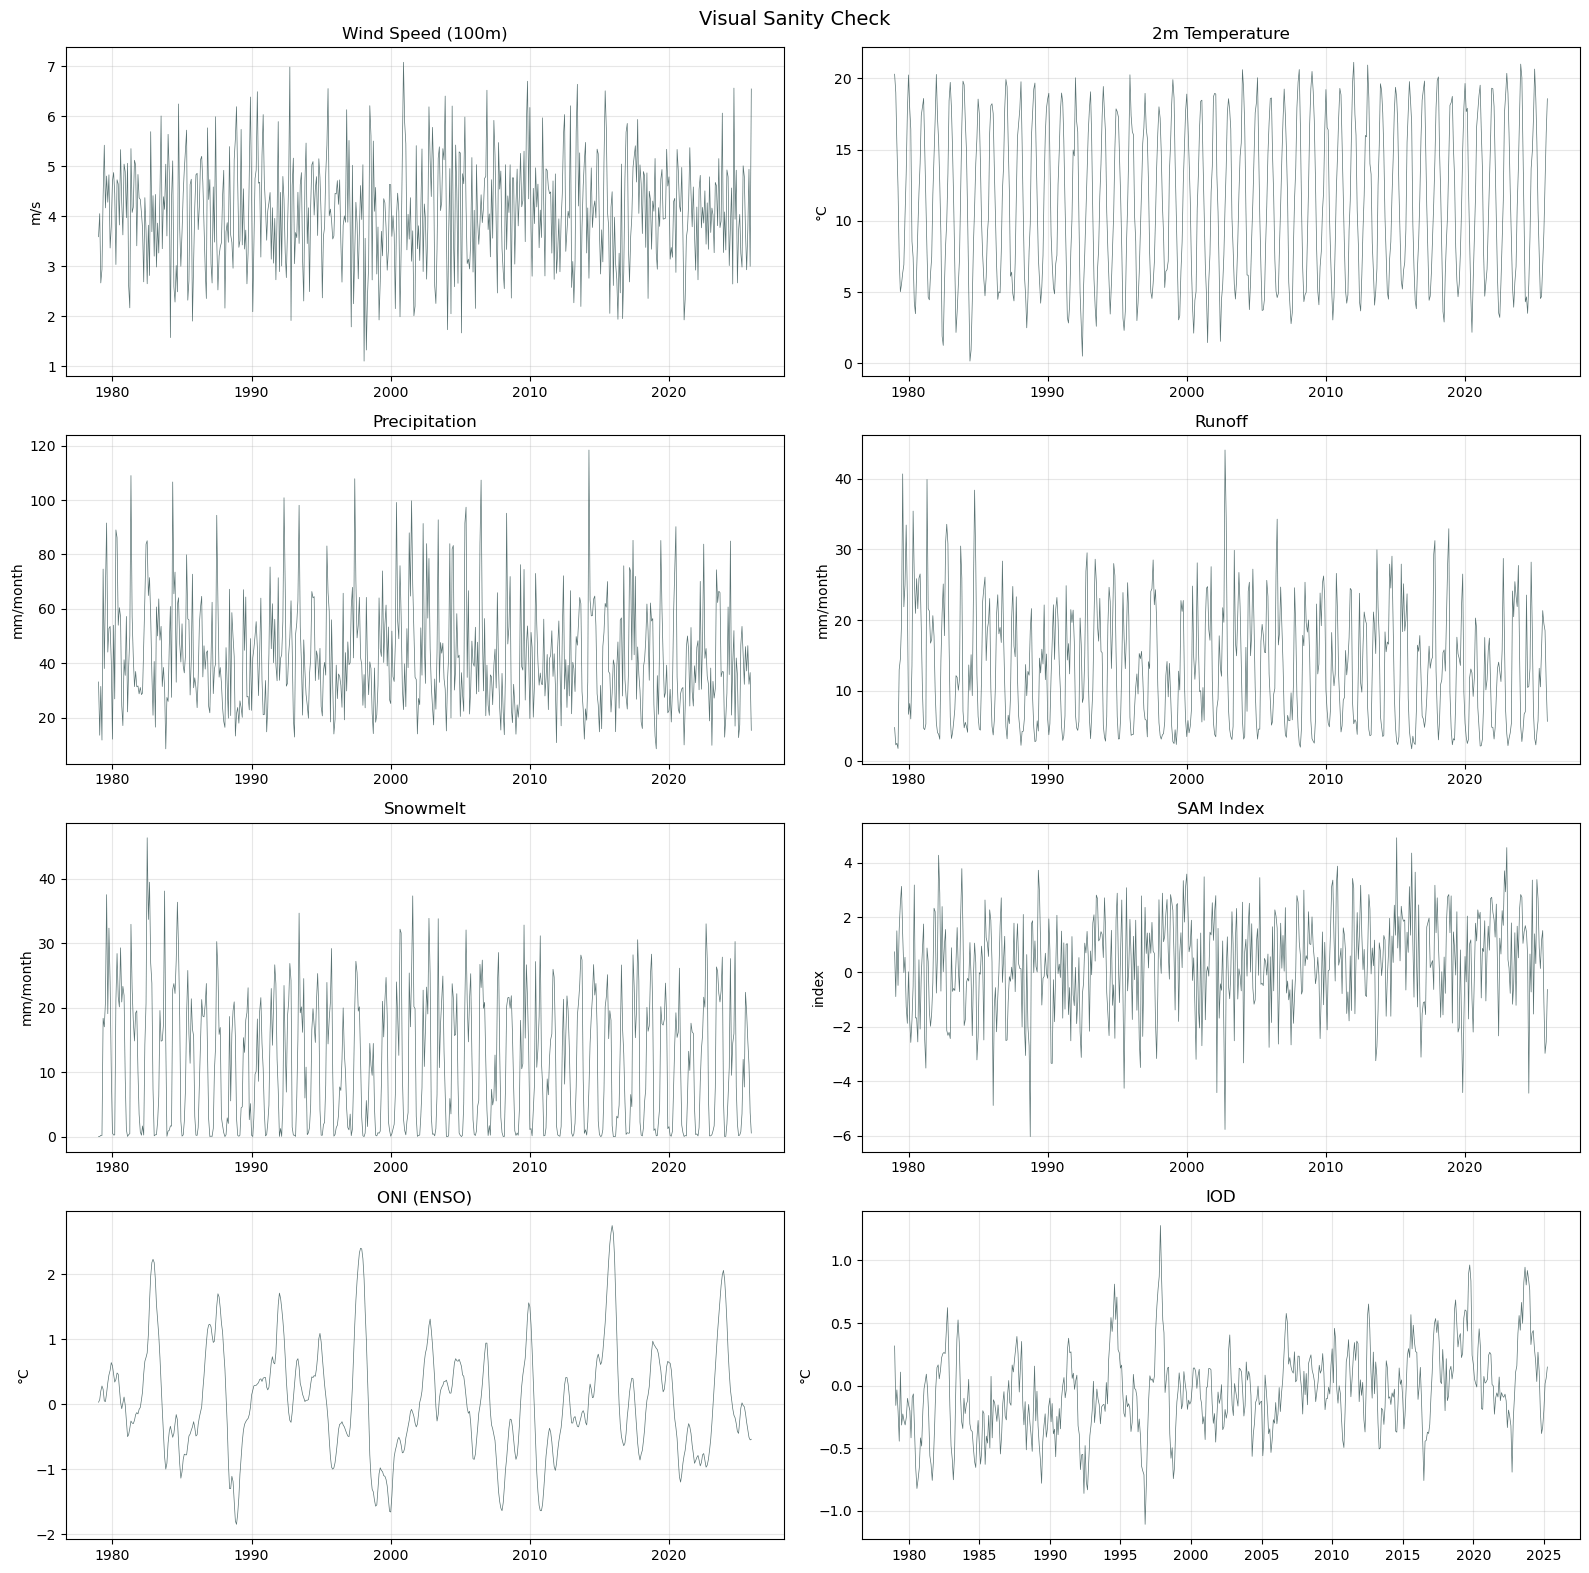

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

variables_to_plot = [
    ("wind_speed", "m/s", "Wind Speed (100m)"),
    ("temperature", "°C", "2m Temperature"),
    ("precipitation", "mm/month", "Precipitation"),
    ("runoff", "mm/month", "Runoff"),
    ("snowmelt", "mm/month", "Snowmelt"),
    ("sam", "index", "SAM Index"),
    ("oni", "°C", "ONI (ENSO)"),
    ("iod", "°C", "IOD"),
]

for ax, (var, unit, title) in zip(axes.flat, variables_to_plot):
    if var in df_combined.columns:
        ax.plot(
            df_combined.index,
            df_combined[var],
            color="darkslategrey",
            linewidth=0.5,
            alpha=0.8,
        )
        ax.set_title(title)
        ax.set_ylabel(unit)
        ax.grid(True, alpha=0.3)
    else:
        ax.set_visible(False)

plt.suptitle("Visual Sanity Check", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/raw_sanity_check.png", dpi=150, bbox_inches="tight")
plt.show()

### Seasonal Cycle Checks

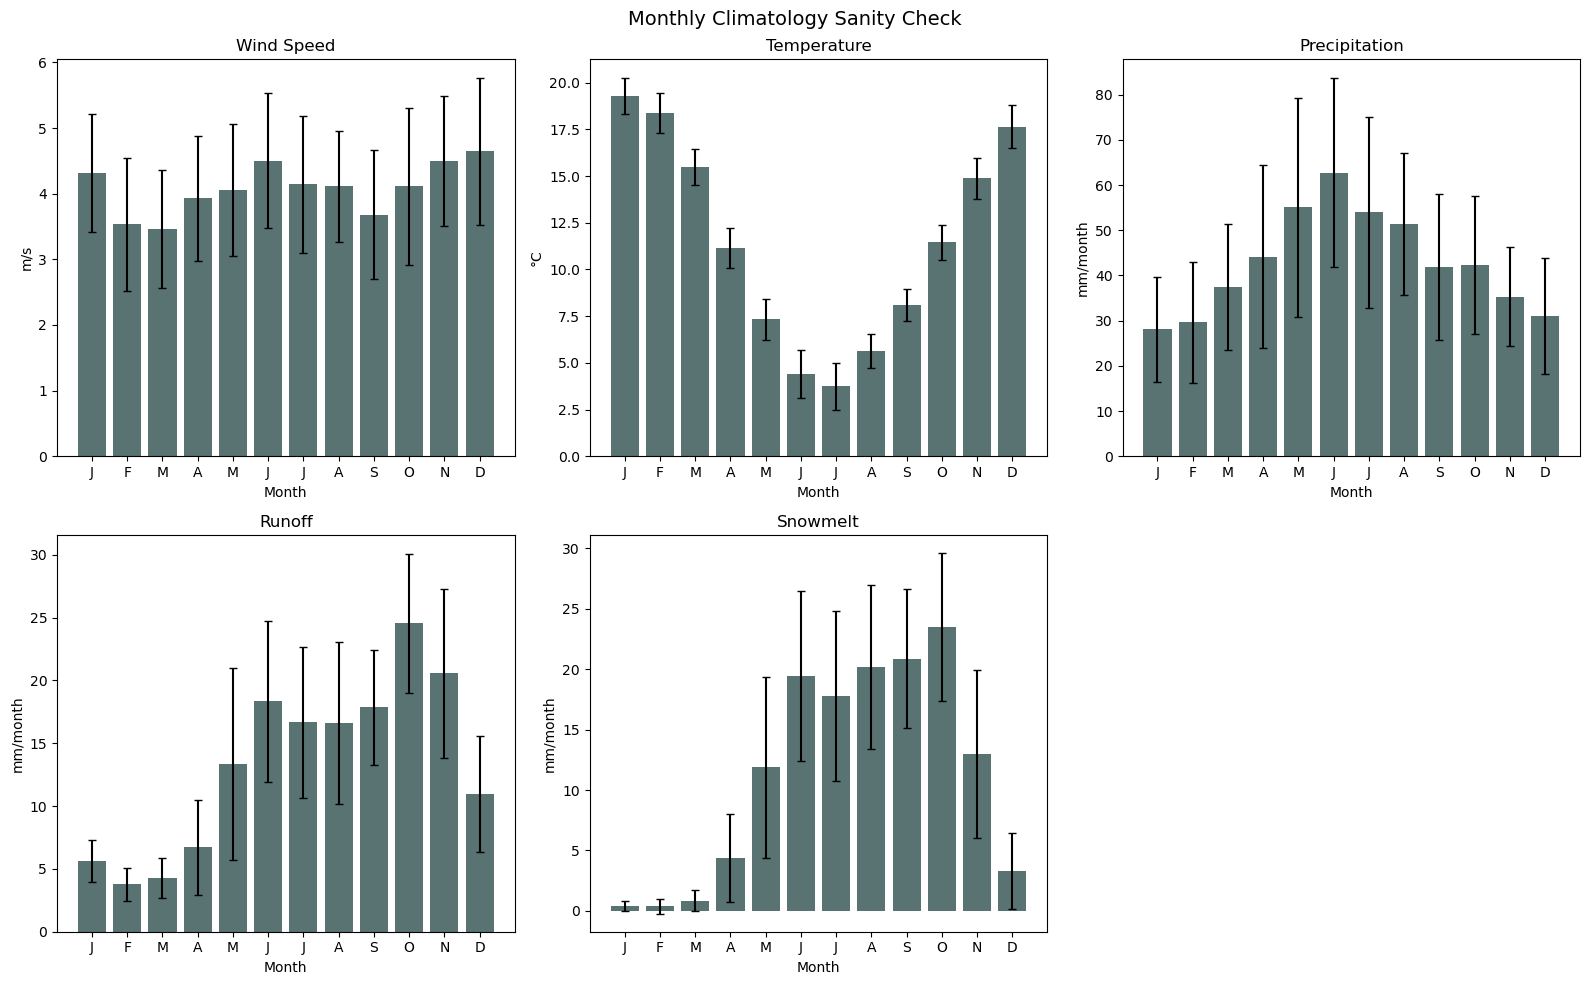

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

era5_vars = [
    ("wind_speed", "m/s", "Wind Speed"),
    ("temperature", "°C", "Temperature"),
    ("precipitation", "mm/month", "Precipitation"),
    ("runoff", "mm/month", "Runoff"),
    ("snowmelt", "mm/month", "Snowmelt"),
]

for ax, (var, unit, title) in zip(axes.flat, era5_vars):
    monthly_mean = df_combined.groupby(df_combined.index.month)[var].mean()
    monthly_std = df_combined.groupby(df_combined.index.month)[var].std()

    ax.bar(
        range(1, 13),
        monthly_mean,
        yerr=monthly_std,
        capsize=3,
        color="darkslategrey",
        alpha=0.8,
    )
    ax.set_title(title)
    ax.set_ylabel(unit)
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
axes.flat[-1].set_visible(False)

plt.suptitle("Monthly Climatology Sanity Check", fontsize=14)
plt.tight_layout()
plt.savefig(
    "../results/figures/seasonal_cycles_check.png", dpi=150, bbox_inches="tight"
)
plt.show()

### Region Map

/home/sgosmyt2/miniconda3/envs/patagonia-energy/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/sgosmyt2/miniconda3/envs/patagonia-energy/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/sgosmyt2/miniconda3/envs/patagonia-energy/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/sgosmyt2/miniconda3/envs/patagonia-energy/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Down

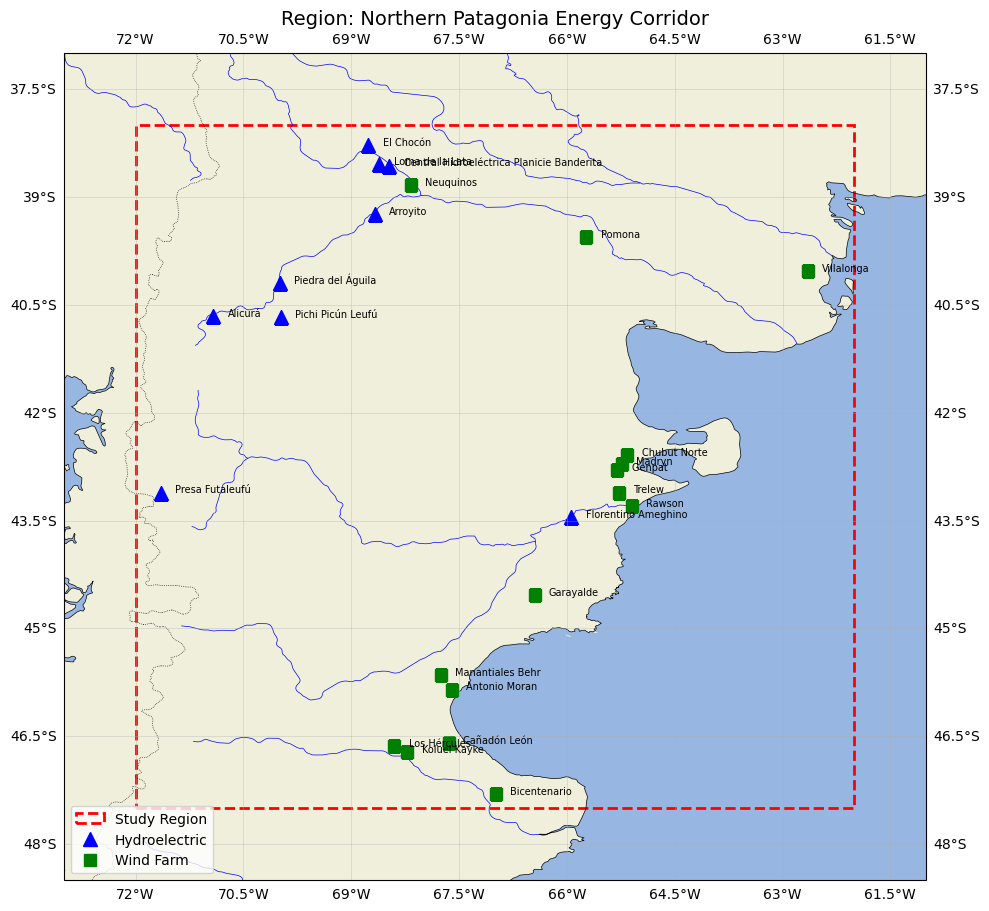

In [19]:
fig, ax = plt.subplots(
    1, 1, figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent(
    [WEST - 1, EAST + 1, SOUTH - 1, NORTH + 1],
    crs=ccrs.PlateCarree(),
)
ax.add_feature(
    cfeature.LAND,
)
ax.add_feature(
    cfeature.OCEAN,
)
ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.5,
)
ax.add_feature(
    cfeature.BORDERS,
    linestyle=":",
    linewidth=0.5,
)
ax.add_feature(
    cfeature.RIVERS,
    linewidth=0.5,
    color="blue",
)
bbox = Rectangle(
    (WEST, SOUTH),
    EAST - WEST,
    NORTH - SOUTH,
    linewidth=2,
    facecolor="none",
    edgecolor="red",
    transform=ccrs.PlateCarree(),
    linestyle="--",
    label="Study Region",
)
ax.add_patch(bbox)

hydro_plants = {
    "El Chocón": (-38.27, -68.76),
    "Piedra del Águila": (-40.19, -69.99),
    "Alicurá": (-40.65, -70.92),
    "Pichi Picún Leufú": (-40.67, -69.98),
    "Arroyito": (-39.23, -68.67),
    "Florentino Ameghino": (-43.45, -65.94),
    "Loma de la Lata": (-38.54, -68.61),
    "Central Hidroeléctrica Planicie Banderita": (-38.56, -68.47),
    "Presa Futaleufú": (-43.11, -71.65),
}

wind_farms = {
    "Rawson": (-43.30, -65.10),
    "Trelew": (-43.11, -65.28),
    "Chubut Norte": (-42.59, -65.16),
    "Madryn": (-42.71, -65.24),
    "Genpat ": (-42.80, -65.30),
    "Manantiales Behr": (-45.65, -67.75),
    "Antonio Moran": (-45.85, -67.60),
    "Cañadón León": (-46.59, -67.64),
    "Bicentenario": (-47.30, -66.99),
    "Los Hércules": (-46.64, -68.40),
    "Koluel Kayke": (-46.72, -68.22),
    "Pomona": (-39.56, -65.73),
    "Neuquinos": (-38.83, -68.17),
    "Garayalde": (-44.53, -66.45),
    "Villalonga": (-40.03, -62.65),
}

for name, (lat, lon) in hydro_plants.items():
    ax.plot(lon, lat, "b^", markersize=10, transform=ccrs.PlateCarree())
    ax.text(lon + 0.2, lat, name, fontsize=7, transform=ccrs.PlateCarree())

for name, (lat, lon) in wind_farms.items():
    ax.plot(lon, lat, "gs", markersize=8, transform=ccrs.PlateCarree())
    ax.text(lon + 0.2, lat, name, fontsize=7, transform=ccrs.PlateCarree())

ax.plot([], [], "b^", markersize=10, label="Hydroelectric")
ax.plot([], [], "gs", markersize=8, label="Wind Farm")
ax.legend(loc="lower left", fontsize=10)
ax.set_title("Region: Northern Patagonia Energy Corridor", fontsize=14)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig("../results/figures/region_map.png", dpi=200, bbox_inches="tight")
plt.show()

## Save Everything

In [20]:
# Save processed ERA5 data
df_era5.to_csv(os.path.join(PROCESSED_DIR, "era5_monthly.csv"))
print(f"Saved ERA5 data: {df_era5.shape}")

# Save climate indices
df_indices = sam_monthly.join(oni_monthly, how="outer").join(iod_monthly, how="outer")
df_indices = df_indices.loc[f"{YEAR_START}":f"{YEAR_END}"]
df_indices.to_csv(os.path.join(PROCESSED_DIR, "climate_indices.csv"))
print(f"Saved climate indices: {df_indices.shape}")

# Save combined dataset
df_combined.to_csv(os.path.join(PROCESSED_DIR, "combined_dataset.csv"))
print(f"Saved combined dataset: {df_combined.shape}")

# Save the masked ERA5 spatial data for composite maps in Notebook 3
ds_masked.to_netcdf(os.path.join(PROCESSED_DIR, "era5_masked_spatial.nc"))
print("Saved masked spatial data for composite analysis")

Saved ERA5 data: (564, 5)
Saved climate indices: (564, 3)
Saved combined dataset: (564, 8)
Saved masked spatial data for composite analysis


## Conclusion

In [21]:
print((" " * 17) + "Data Collection Summary")
print("=" * 61)
print(f"\nStudy region: {NORTH}°N to {SOUTH}°S, {WEST}°W to {EAST}°E")
print(
    f"Period: {df_combined.index[0].strftime('%Y-%m')} to {df_combined.index[-1].strftime('%Y-%m')}"
)
print(f"Total months: {len(df_combined)}")
print(f"\nERA5 variables: {list(df_era5.columns)}")
print(
    f"Climate indices: {[c for c in df_combined.columns if c not in df_era5.columns]}"
)
print("\nMissing values:")
print(df_combined.isna().sum())
print("\nFiles saved:")
print("  data/processed/era5_monthly.csv")
print("  data/processed/climate_indices.csv")
print("  data/processed/combined_dataset.csv")
print("  data/processed/era5_masked_spatial.nc")

                 Data Collection Summary

Study region: -38.0°N to -47.5°S, -72.0°W to -62.0°E
Period: 1979-01 to 2025-12
Total months: 564

ERA5 variables: ['wind_speed', 'temperature', 'precipitation', 'runoff', 'snowmelt']
Climate indices: ['sam', 'oni', 'iod']

Missing values:
wind_speed       0
temperature      0
precipitation    0
runoff           0
snowmelt         0
sam              0
oni              0
iod              8
dtype: int64

Files saved:
  data/processed/era5_monthly.csv
  data/processed/climate_indices.csv
  data/processed/combined_dataset.csv
  data/processed/era5_masked_spatial.nc
